# Observation Collection Plotting
This script defines a utility to visualize various observation types (Angular, Range, Doppler, Position) stored within a TudatPy `ObservationCollection`.

In [1]:
# %%
from tudatpy.estimation import observable_models_setup
from tudatpy.estimation.observations.observations_processing import observation_parser
import matplotlib.pyplot as plt
import numpy as np
from tudatpy.estimation import observations

%% [markdown]
## Plotting Function

In [9]:
# %%
def plot_observation_collection(observation_collection: observations.ObservationCollection):
    """
    Plots the contents of a TudatPy ObservationCollection.

    This function creates a separate figure for each unique observation set (i.e., link)
    and adapts the plots based on the observable type. For example, it will create
    a two-panel plot for angular position (RA/DEC) and a single-panel plot for range.

    Parameters
    ----------
    observation_collection : tudatpy.estimation.observations.ObservationCollection
        The collection of observations to be plotted.
    """
    if not isinstance(observation_collection, observations.ObservationCollection):
        raise TypeError("Input must be a tudatpy.estimation.observations.ObservationCollection")


    for observable_type in observation_collection.get_observable_types():
        observable_type_parser = observation_parser(observable_type)
        parsed_observations_by_type = observation_collection.get_concatenated_observations(observable_type_parser)
        parsed_times_by_type = observation_collection.get_concatenated_observation_times(observable_type_parser)

        if observable_type == observable_models_setup.model_settings.angular_position_type:
            # Right Ascension plot
            fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 9))
            labels = ["Right Ascension (deg)", "Declination (deg)"]

            obs_array = parsed_observations_by_type.reshape(-1, 2)

            colors = ['#1f77b4', '#ff7f0e'] # Standard blue, orange

            for idx, ax in enumerate(axes):
                # Column 'idx' corresponds to X (0), Y (1), or Z (2)
                ax.scatter(parsed_times_by_type, np.rad2deg(obs_array[:, idx]),  color=colors[idx])
                ax.set_ylabel(labels[idx])
                ax.grid(True)

                plt.title("RA/Dec Observations")

        # Case 2: One-Way Range - Size 1
        elif observable_type == observable_models_setup.model_settings.one_way_range_type:
            plt.figure(figsize=(10, 6))
            plt.scatter(parsed_times_by_type, parsed_observations_by_type / 1000)
            plt.ylabel("One-Way Range (km)")
            plt.xlabel("Time (seconds since J2000 TDB)")
            plt.title("One-Way Range Observations")
            plt.grid(True)
            plt.tight_layout(rect=[0, 0, 1, 0.95])

        # Case 3: One-Way Doppler - Size 1
        elif observable_type == observable_models_setup.model_settings.one_way_averaged_doppler_type:
            plt.figure(figsize=(10, 6))
            plt.plot(parsed_times_by_type, parsed_observations_by_type)
            plt.ylabel("One-Way Doppler (Hz)")
            plt.xlabel("Time (seconds since J2000 TDB)")
            plt.title("One-Way Doppler Observations")
            plt.grid(True)
            plt.tight_layout(rect=[0, 0, 1, 0.95])

        # Case 4: Position Observable (X, Y, Z) - Size 3
        elif observable_type == observable_models_setup.model_settings.position_observable_type:
            # num_observations must match len(parsed_times_by_type)
            obs_array = parsed_observations_by_type.reshape(-1, 3)

            fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 9))

            labels = ["X position (km)", "Y position (km)", "Z position (km)"]
            colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Standard blue, orange, green

            for idx, ax in enumerate(axes):
                # Column 'idx' corresponds to X (0), Y (1), or Z (2)
                ax.plot(parsed_times_by_type, obs_array[:, idx] / 1000, color=colors[idx])
                ax.set_ylabel(labels[idx])
                ax.grid(True)

    plt.xlabel("Time (seconds since J2000 TDB)")
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Display all the figures that were created
    plt.show()

%% [markdown]
## Main Execution Block
This block creates sample data for Starship and Mars observations, merges them, and calls the plot function.

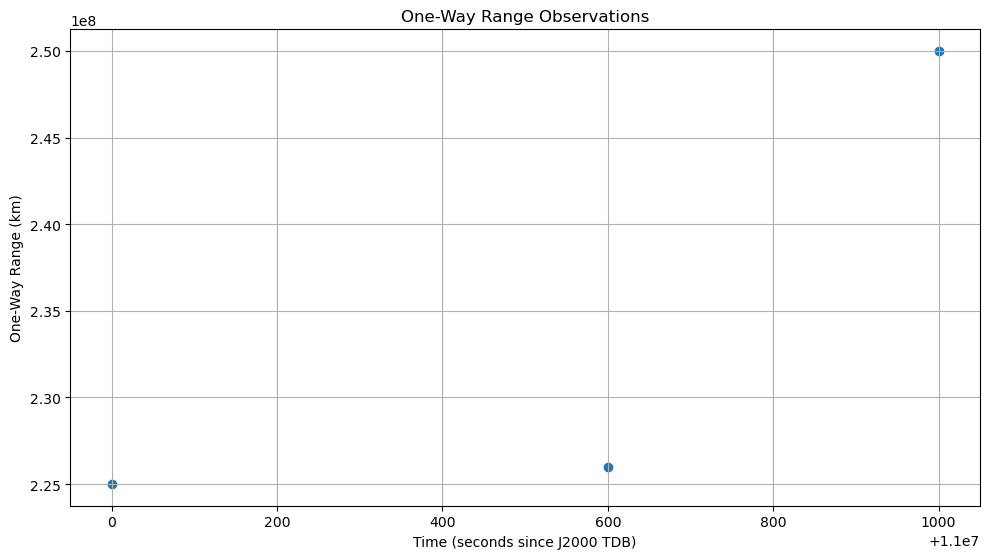

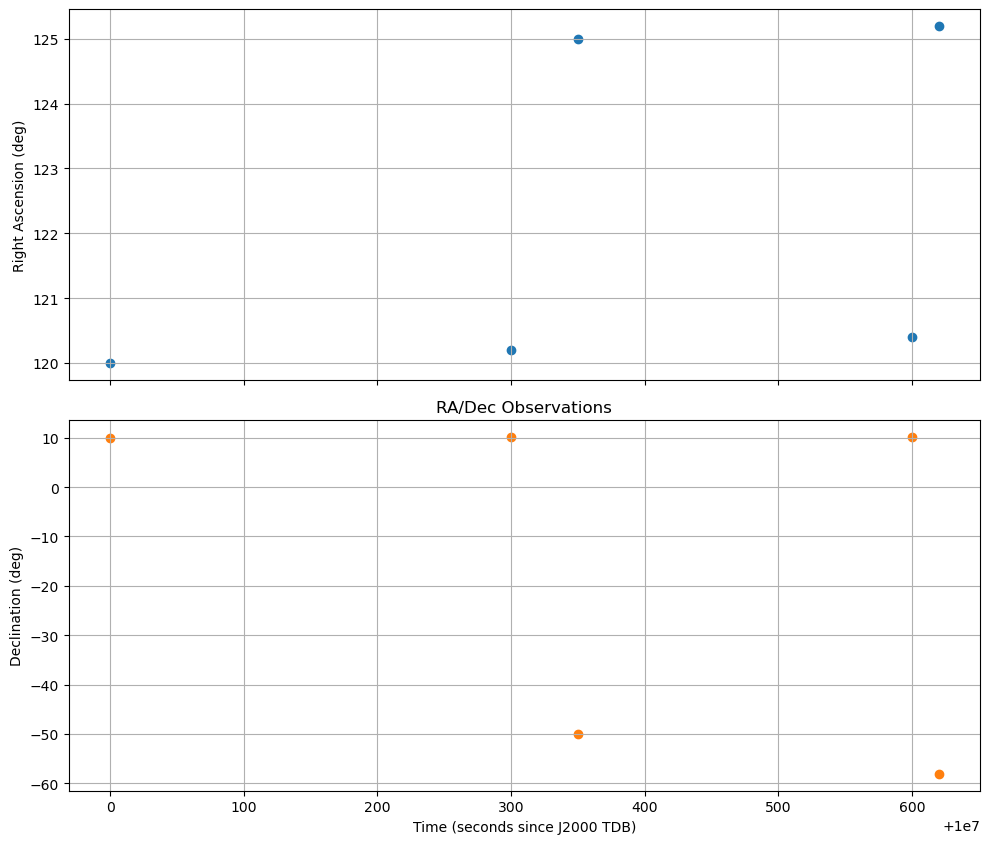

In [13]:
# %%
if __name__ == '__main__':
    # --- Create a sample ObservationCollection ---

    # Define link ends for two different observation sets
    link_ends_angular_goldstone = {
        observable_models_setup.links.transmitter: observable_models_setup.links.body_origin_link_end_id("Starship"),
        observable_models_setup.links.receiver: observable_models_setup.links.body_reference_point_link_end_id("Earth", "Goldstone")
    }

    link_ends_angular_simaos_apartment = {
        observable_models_setup.links.transmitter: observable_models_setup.links.body_origin_link_end_id("Starship"),
        observable_models_setup.links.receiver: observable_models_setup.links.body_reference_point_link_end_id("Earth", "SIMAOS_APT")
    }

    link_ends_range = {
        observable_models_setup.links.transmitter: observable_models_setup.links.body_origin_link_end_id("Mars"),
        observable_models_setup.links.receiver: observable_models_setup.links.body_reference_point_link_end_id("Earth", "Canberra")
    }

    # Create angular position data
    angular_times_goldstone = np.array([1.0e7, 1.0e7 + 300, 1.0e7 + 600])
    angular_times_simaos_apartment = np.array([1.0e7 + 350, 1.0e7 + 620])
    angular_obs_goldstone = np.array([
        [np.deg2rad(120.0), np.deg2rad(10.0)],
        [np.deg2rad(120.2), np.deg2rad(10.1)],
        [np.deg2rad(120.4), np.deg2rad(10.2)]
    ])

    angular_obs_simaos_apartment = np.array([
        [np.deg2rad(125.0), np.deg2rad(-50.0)],
        [np.deg2rad(125.2), np.deg2rad(-58.1)],
    ])
    angular_set_goldstone = observations.create_single_observation_set(
        observable_models_setup.model_settings.angular_position_type,
        link_ends_angular_goldstone,
        angular_obs_goldstone,
        angular_times_goldstone,
        observable_models_setup.links.receiver
    )

    angular_set_simaos_apartment = observations.create_single_observation_set(
        observable_models_setup.model_settings.angular_position_type,
        link_ends_angular_simaos_apartment,
        angular_obs_simaos_apartment,
        angular_times_simaos_apartment,
        observable_models_setup.links.receiver
    )

    # Create range data
    range_times = np.array([1.1e7, 1.1e7 + 600, 1.1e7 + 1000])
    range_obs = np.array([
        [2.25e11],  # 2.25e8 km in meters
        [2.26e11],
        [2.50e11]
    ])
    range_set = observations.create_single_observation_set(
        observable_models_setup.model_settings.one_way_range_type,
        link_ends_range,
        range_obs,
        range_times,
        observable_models_setup.links.receiver
    )

    # Combine into a collection
    range_observation_collection = observations.ObservationCollection([range_set])
    angle_observation_collection = observations.ObservationCollection([angular_set_goldstone, angular_set_simaos_apartment])

    merged_obs_coll = observations.merge_observation_collections([range_observation_collection, angle_observation_collection])

    # --- Plot the collection ---
    plot_observation_collection(merged_obs_coll )